In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du dataSet

In [4]:
df = pd.read_csv('dataset_reseau.csv')
df = df.copy()

# Affichage 

In [5]:
df.head(10)

,machine_id,os_type,duree_connexion,nombre_requetes,volume_donnees,statut_connexion
0,M1381,linux,124.841713,80,464.209300,success
1,M996,linux,203.399243,212,696.590874,Succes
2,M1411,macos,71.099503,213,430.462099,Success
3,M1448,windows,150.118079,216,341.491727,Fail
4,M1448,Andriod,182.837035,79,259.873768,Succes
5,M167,Andriod,143.479982,224,289.311325,Success
6,M127,Windows,113.242452,198,312.953557,Failed
7,M1247,Android,110.820160,168,679.286073,success
8,M1338,Windows,145.661309,234,424.517234,Succes
9,M162,MacOS,156.610195,258,601.261817,fail


In [6]:
df.tail(10)

,machine_id,os_type,duree_connexion,nombre_requetes,volume_donnees,statut_connexion
10190,M37,Linus,74.182716,234,215.697087,fail
10191,M744,Android,140.012344,267,461.114426,Fail
10192,M72,Andriod,126.084190,146,562.799241,fail
10193,M1460,Linux,99.637282,227,440.131910,Failed
10194,M943,MacOS,54.114133,249,NaN,fail
10195,M1331,MacOS,152.549519,280,519.291287,fail
10196,M830,macos,78.707837,154,748.516228,success
10197,M8,linux,109.976522,197,530.399940,Succes
10198,M1248,windows,105.207239,250,684.211355,Success
10199,M1275,Linus,154.154944,153,366.478292,Succes


# Nombre de ligne et colonne

In [7]:
df.shape

(10200, 6)

# Type de variable

In [9]:
df.dtypes

machine_id              str
os_type                 str
duree_connexion     float64
nombre_requetes       int64
volume_donnees      float64
statut_connexion        str
dtype: object

- Affichage des colonnes

In [9]:
df.columns.tolist()

['machine_id',
 'os_type',
 'duree_connexion',
 'nombre_requetes',
 'volume_donnees',
 'statut_connexion']

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   machine_id        10200 non-null  str    
 1   os_type           10200 non-null  str    
 2   duree_connexion   9667 non-null   float64
 3   nombre_requetes   10200 non-null  int64  
 4   volume_donnees    9699 non-null   float64
 5   statut_connexion  10200 non-null  str    
dtypes: float64(2), int64(1), str(3)
memory usage: 478.3 KB


In [10]:
df.describe()

,duree_connexion,nombre_requetes,volume_donnees
count,9667.000000,10200.000000,9699.000000
mean,137.750628,199.042451,573.192602
std,125.556422,60.617558,557.366581
min,-25.753534,-24.000000,-43.984643
25%,93.851389,157.000000,399.976673
50%,120.775692,200.000000,502.638632
75%,149.055586,240.000000,608.036373
max,1197.000000,407.000000,5978.000000


# Observation du dataset

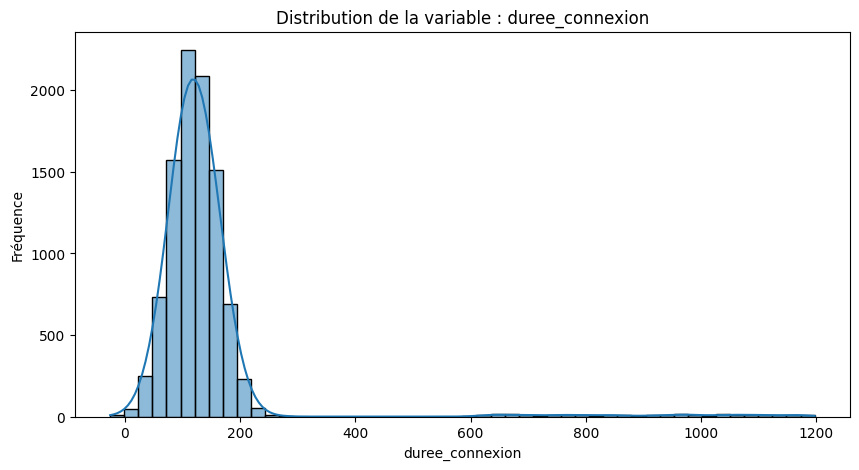

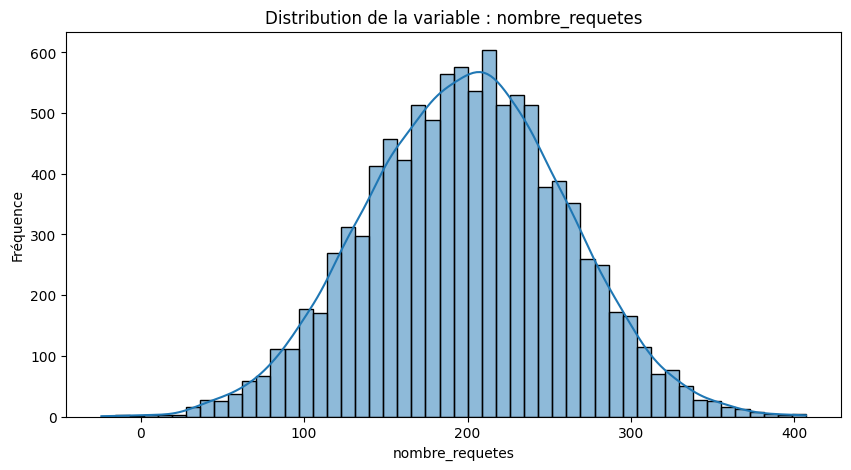

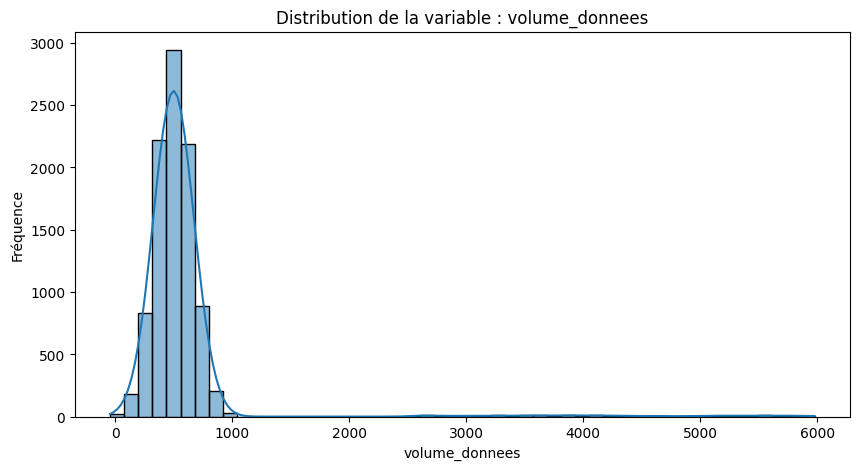

In [29]:
for col in df.select_dtypes(include=['int', 'float']):
    plt.figure(figsize=(10, 5))
    
    sns.histplot(
        data=df[col],
        kde=True,
        bins=50
    )
    plt.title(f"Distribution de la variable : {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

<Figure size 1000x500 with 0 Axes>

/tmp/ipykernel_44651/1576730110.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


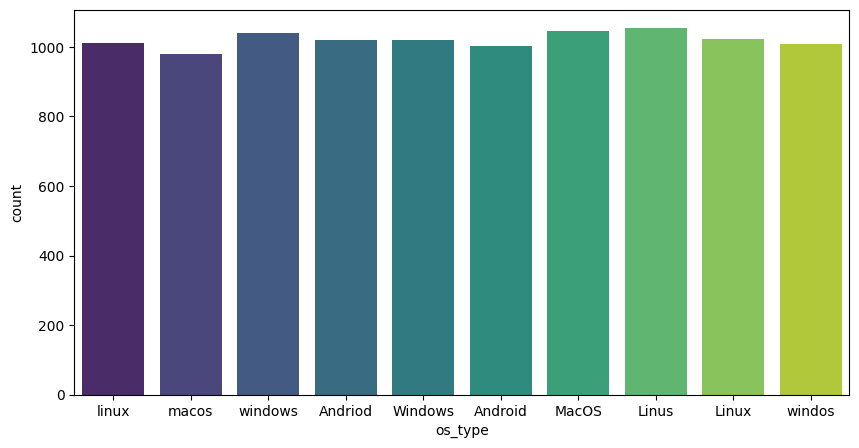

/tmp/ipykernel_44651/1576730110.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


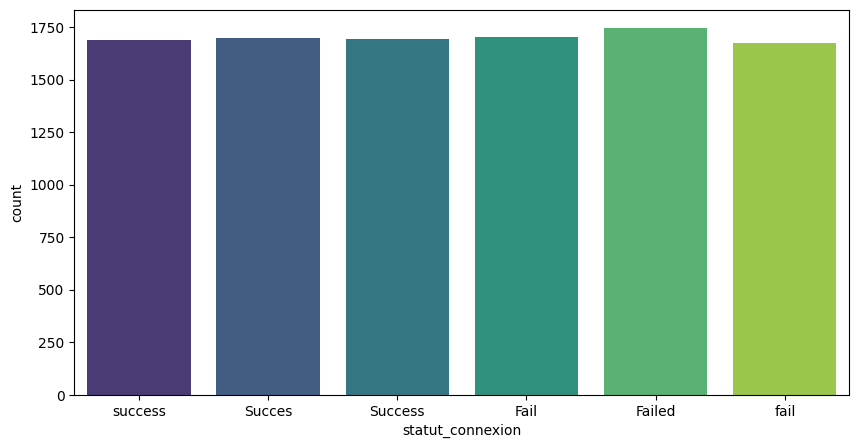

In [23]:
for col in df.select_dtypes('str'):
    plt.figure(figsize=(10,5))

    if col != 'machine_id':
        sns.countplot(
            x=df[col],
            palette='viridis'
        )

    plt.show()

# Detection d'anomalie

## observer les valeurs manquantes

In [13]:
df.isnull().sum()

machine_id            0
os_type               0
duree_connexion     533
nombre_requetes       0
volume_donnees      501
statut_connexion      0
dtype: int64

In [31]:
(df.isna().sum() / df.shape[0]) * 100

machine_id          0.000000
os_type             0.000000
duree_connexion     5.225490
nombre_requetes     0.000000
volume_donnees      4.911765
statut_connexion    0.000000
dtype: float64

total de valeur manquantes dans le dataset

In [16]:
total_nan = df.isnull().sum().sum()

print(f"Nombre total de cellules vides dans le dataset : {total_nan}")

Nombre total de cellules vides dans le dataset : 1034


## Les Doublons

In [17]:
df.duplicated().value_counts()

False    10000
True       200
Name: count, dtype: int64

## Les irrégularités

In [25]:
# Analyse fréquentielle pour chaque colonne
analyses = [df[col].value_counts() for col in df.columns]

for col in df.columns:
    if col != 'machine_id':
        print(f"\n--- Distribution de la colonne : {col} ---")
        print(df[col].value_counts().head(10)) 


--- Distribution de la colonne : os_type ---
os_type
Linus      1054
MacOS      1046
windows    1041
Linux      1023
Andriod    1020
Windows    1019
linux      1010
windos     1007
Android    1001
macos       979
Name: count, dtype: int64

--- Distribution de la colonne : duree_connexion ---
duree_connexion
705.000000     3
1078.000000    3
681.000000     3
642.000000     3
1137.000000    3
784.000000     2
88.951119      2
75.532276      2
151.925248     2
120.639504     2
Name: count, dtype: int64

--- Distribution de la colonne : nombre_requetes ---
nombre_requetes
209    90
185    78
195    77
218    75
201    73
204    72
221    72
176    72
216    71
206    71
Name: count, dtype: int64

--- Distribution de la colonne : volume_donnees ---
volume_donnees
2656.000000    3
356.112712     2
395.999884     2
730.145848     2
193.583741     2
324.375007     2
578.243540     2
567.211945     2
593.105942     2
419.549857     2
Name: count, dtype: int64

--- Distribution de la colonne : 

- **os_type**
    - Linux, linux, linus
    - windows, Windows, windos
    - macos, MacOS
    - Android, Andriod
- **statut_connexion**
    - success, Succes, Success
    - Failed, fail, Fail

In [26]:
df.describe()

,duree_connexion,nombre_requetes,volume_donnees
count,9667.000000,10200.000000,9699.000000
mean,137.750628,199.042451,573.192602
std,125.556422,60.617558,557.366581
min,-25.753534,-24.000000,-43.984643
25%,93.851389,157.000000,399.976673
50%,120.775692,200.000000,502.638632
75%,149.055586,240.000000,608.036373
max,1197.000000,407.000000,5978.000000


In [28]:
# Automatisation du calcul du skewness pour les variables numériques
for col in df.select_dtypes(include='number'):
    sym = df[col].skew()
    print(f'{col} : ', sym)

duree_connexion :  5.866800953279415
nombre_requetes :  -0.0179819830553768
volume_donnees :  6.791914142466121


## Boite a moustache

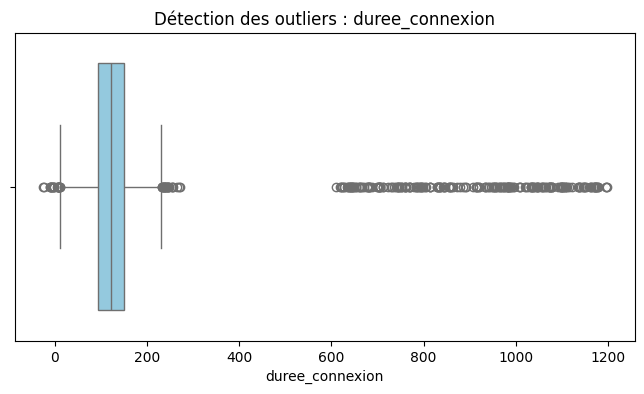

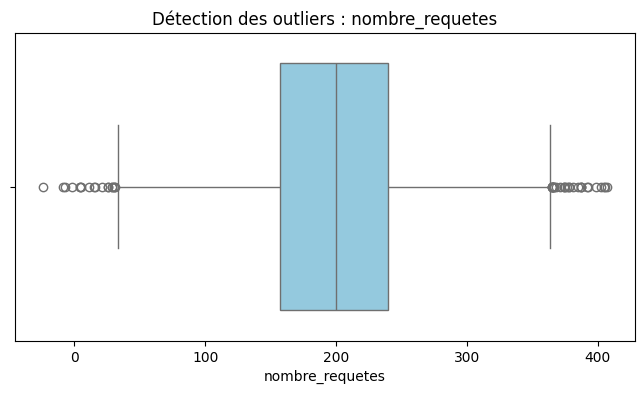

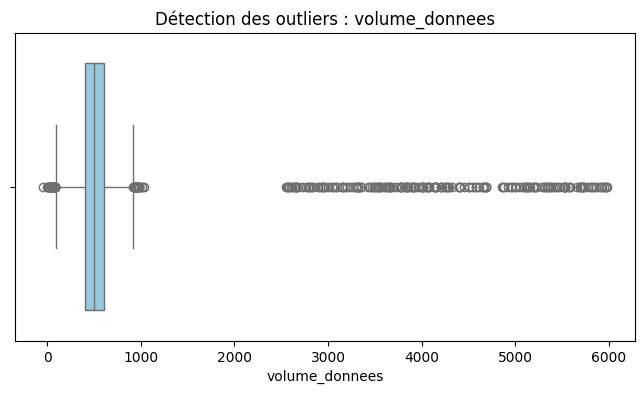

In [30]:
# Visualisation des outliers pour chaque variable numérique
for col in df.select_dtypes(include=['int', 'float']):
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f"Détection des outliers : {col}")
    plt.show()

## Correction

Avant suppression 

In [31]:
df.shape

(10200, 6)

In [34]:
dp =df.duplicated().sum()
print(f'nombre de lignes dupliquée : ', dp)

nombre de lignes dupliquée :  200


In [35]:
df = df.drop_duplicates()

Après suppression

In [36]:
df.shape

(10000, 6)

Correction des irrégularité

In [41]:
# Exemple de correction pour os_type
corrections_os = {
    'linus': 'linux',
    'windos': 'windows',
    'andriod': 'android',
    'macos': 'macos'
}

# Normalisation globale
df['os_type'] = df['os_type'].str.lower().str.strip().replace(corrections_os)
df['statut_connexion'] = df['statut_connexion'].str.lower().str.strip().replace({'succes': 'success', 'fail': 'failed'})

In [42]:
# Analyse fréquentielle pour chaque colonne
analyses = [df[col].value_counts() for col in df.select_dtypes(include=['string', 'object'])]

for col in df.select_dtypes(include=['string', 'object']):
    if col != 'machine_id':
        print(f"\n--- Distribution de la colonne : {col} ---")
        print(df[col].value_counts().head(10)) 


--- Distribution de la colonne : os_type ---
os_type
linux      3029
windows    3021
android    1979
macos      1971
Name: count, dtype: int64

--- Distribution de la colonne : statut_connexion ---
statut_connexion
failed     5034
success    4966
Name: count, dtype: int64


- Valeurs manquantes

In [ ]:
for col in df.select_dtypes(include='number'):
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

# Vérification 
print("Valeurs manquantes après traitement :")
print(df.isnull().sum().sum())

Valeurs manquantes après traitement :
0


- Traitement des valeurs aberrantes avec la méhode IQR

In [46]:
for col in df.select_dtypes('number'):
    print(f"============== {col} ===============")
    
    # 1. Calcul des quartiles 
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    # 2. Calcul de l'IQR 
    IQR = Q3 - Q1
    print(f'IQR : {IQR}')
    
    # 3. Détermination des bornes de Tukey
    borne_min = Q1 - 1.5 * IQR
    borne_max = Q3 + 1.5 * IQR
    print(f'Borne min : {borne_min} | Borne max : {borne_max}')
    
    # 4. Remplacement des valeurs aberrantes par la médiane
    mediane = df[col].median()
    df.loc[df[col] > borne_max, col] = mediane
    df.loc[df[col] < borne_min, col] = mediane

============== duree_connexion ===============
IQR : 47.99493582970646
Borne min : 24.170276342077855 | Borne max : 216.1500196609037
============== nombre_requetes ===============
IQR : 82.0
Borne min : 35.0 | Borne max : 363.0
============== volume_donnees ===============
IQR : 181.33451147918566
Borne min : 136.08958434130335 | Borne max : 861.427630258046


# Après nettoyage

In [47]:
df.describe()

,duree_connexion,nombre_requetes,volume_donnees
count,10000.000000,10000.000000,10000.000000
mean,119.990545,198.854400,499.399649
std,35.821218,59.164701,135.986177
min,24.628223,35.000000,136.186836
25%,96.486021,158.000000,409.364327
50%,120.771469,200.000000,502.413429
75%,143.722508,240.000000,587.734357
max,215.903340,362.000000,861.203669


# Sauvegarde

In [48]:
df.to_csv('clean_dataset_reseau.csv')

In [50]:
dt_clean = pd.read_csv('clean_dataset_reseau.csv')

In [51]:
dt_clean.describe()

,Unnamed: 0,duree_connexion,nombre_requetes,volume_donnees
count,10000.00000,10000.000000,10000.000000,10000.000000
mean,4999.50000,119.990545,198.854400,499.399649
std,2886.89568,35.821218,59.164701,135.986177
min,0.00000,24.628223,35.000000,136.186836
25%,2499.75000,96.486021,158.000000,409.364327
50%,4999.50000,120.771469,200.000000,502.413429
75%,7499.25000,143.722508,240.000000,587.734357
max,9999.00000,215.903340,362.000000,861.203669
